In [1]:
import torch
# Centralized Quality Metrics Function with Artifact Avoidance
def calculate_quality_metrics(original, reconstructed, crop_pixels=5):
    """
    Calculate PSNR and SSIM between two tensors, avoiding edge artifacts by cropping border pixels.
    
    Args:
        original: Original tensor (can be single image or batch)
        reconstructed: Reconstructed tensor (same shape as original)
        crop_pixels: Number of pixels to crop from each side (default: 5)
    
    Returns:
        dict: Dictionary containing 'psnr' and 'ssim' values
    """
    # Ensure tensors are float and on CPU for consistency
    orig = original.float().cpu()
    recon = reconstructed.float().cpu()
    
    # Handle different tensor dimensions
    if orig.dim() == 2:  # Single 2D image
        orig = orig.unsqueeze(0)  # Add batch dimension
        recon = recon.unsqueeze(0)
    elif orig.dim() == 4:  # Video tensor (N, C, H, W)
        orig = orig.squeeze(1) if orig.shape[1] == 1 else orig.mean(dim=1)  # Remove channel or average RGB
        recon = recon.squeeze(1) if recon.shape[1] == 1 else recon.mean(dim=1)
    
    # Crop edge pixels to avoid compression artifacts
    if orig.shape[-1] > 2 * crop_pixels and orig.shape[-2] > 2 * crop_pixels:
        orig_cropped = orig[..., crop_pixels:-crop_pixels, crop_pixels:-crop_pixels]
        recon_cropped = recon[..., crop_pixels:-crop_pixels, crop_pixels:-crop_pixels]
    else:
        # If image is too small to crop, use full image but warn
        orig_cropped = orig
        recon_cropped = recon
        print(f"⚠️  Image too small to crop {crop_pixels} pixels, using full image")
    
    # Calculate PSNR
    mse = torch.mean((orig_cropped - recon_cropped) ** 2)
    if mse > 0:
        # Assume normalized input [0, 1] range
        max_val = orig_cropped.max()
        psnr = 20 * torch.log10(max_val / torch.sqrt(mse))
    else:
        psnr = torch.tensor(float('inf'))
    
    # Calculate SSIM
    def ssim_2d(x, y):
        """Calculate SSIM for 2D tensors"""
        mu_x = torch.mean(x)
        mu_y = torch.mean(y)
        
        mu_x_sq = mu_x ** 2
        mu_y_sq = mu_y ** 2
        mu_xy = mu_x * mu_y
        
        sigma_x_sq = torch.var(x)
        sigma_y_sq = torch.var(y)
        sigma_xy = torch.mean((x - mu_x) * (y - mu_y))
        
        # SSIM constants
        c1 = (0.01) ** 2
        c2 = (0.03) ** 2
        
        ssim_val = ((2 * mu_xy + c1) * (2 * sigma_xy + c2)) / \
                   ((mu_x_sq + mu_y_sq + c1) * (sigma_x_sq + sigma_y_sq + c2))
        
        return ssim_val
    
    # Calculate SSIM (average over batch if multiple frames)
    if orig_cropped.dim() == 3:  # Batch of images
        ssim_values = []
        for i in range(orig_cropped.shape[0]):
            ssim_val = ssim_2d(orig_cropped[i], recon_cropped[i])
            ssim_values.append(ssim_val)
        ssim = torch.mean(torch.stack(ssim_values))
    else:  # Single image
        ssim = ssim_2d(orig_cropped, recon_cropped)
    
    return {
        'psnr': psnr.item() if not torch.isinf(psnr) else float('inf'),
        'ssim': ssim.item(),
        'mse': mse.item(),
        'cropped_shape': orig_cropped.shape,
        'crop_pixels': crop_pixels
    }

print("✅ Quality metrics function loaded")
print("   Function: calculate_quality_metrics(original, reconstructed, crop_pixels=5)")
print("   Features: Automatic edge cropping, PSNR & SSIM calculation, batch support")

✅ Quality metrics function loaded
   Function: calculate_quality_metrics(original, reconstructed, crop_pixels=5)
   Features: Automatic edge cropping, PSNR & SSIM calculation, batch support


# Raw Projection Data Overview

This notebook analyzes the raw CT projection data stored in `data/212_Wunderkerze2.h5`.
We'll explore the structure of the HDF5 file and examine the projection data tensor.

## Import Required Libraries

In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os
import torch
from pathlib import Path

# Set up matplotlib for better plots
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['image.cmap'] = 'gray'

print("Libraries imported successfully!")

Libraries imported successfully!


## Load and Explore HDF5 File Structure

In [3]:
# Define the path to the data file
data_path = Path('../data/212_Wunderkerze2.h5')
# data_path = Path('../data/043_AG10_C1mm_0s_subset_20k.h5')
# data_path = Path('../data/cord_water_3_first_4000frames.h5')

# Check if the file exists
if not data_path.exists():
    print(f"Error: File {data_path} does not exist!")
    print(f"Current working directory: {os.getcwd()}")
    print(f"Looking for file at: {data_path.absolute()}")
else:
    print(f"File found: {data_path.absolute()}")
    print(f"File size: {data_path.stat().st_size / (1024**3):.2f} GB")

File found: /Users/lfbarba/GitHub/deep-anomaly-detection/notebooks/../data/212_Wunderkerze2.h5
File size: 120.55 GB


In [18]:
# Open the HDF5 file and explore its structure
def explore_h5_structure(file_path, max_depth=3, current_depth=0):
    """Recursively explore HDF5 file structure"""
    def print_attrs(name, obj):
        indent = "  " * current_depth
        if isinstance(obj, h5py.Dataset):
            print(f"{indent}{name}: Dataset, shape={obj.shape}, dtype={obj.dtype}")
            if obj.attrs:
                for attr_name, attr_val in obj.attrs.items():
                    print(f"{indent}  - {attr_name}: {attr_val}")
        elif isinstance(obj, h5py.Group):
            print(f"{indent}{name}: Group")
            if obj.attrs:
                for attr_name, attr_val in obj.attrs.items():
                    print(f"{indent}  - {attr_name}: {attr_val}")
            if current_depth < max_depth:
                for key in obj.keys():
                    explore_h5_structure(obj[key], max_depth, current_depth + 1)
    
    if isinstance(file_path, (str, Path)):
        with h5py.File(file_path, 'r') as f:
            print(f"HDF5 File Structure: {file_path}")
            print("=" * 50)
            f.visititems(print_attrs)
    else:
        print_attrs("Current object", file_path)

# Explore the file structure
explore_h5_structure(data_path)

HDF5 File Structure: ../data/cord_water_3_first_4000frames.h5
exchange: Group
  Current object: Dataset, shape=(4000, 2016, 2016), dtype=uint16
  Current object: Dataset, shape=(50, 2016, 2016), dtype=uint16
  Current object: Dataset, shape=(100, 2016, 2016), dtype=uint16
  Current object: Dataset, shape=(4000,), dtype=float64
  Current object: Dataset, shape=(50,), dtype=float64
  Current object: Dataset, shape=(100,), dtype=float64
exchange/data: Dataset, shape=(4000, 2016, 2016), dtype=uint16
exchange/data_dark: Dataset, shape=(50, 2016, 2016), dtype=uint16
exchange/data_white: Dataset, shape=(100, 2016, 2016), dtype=uint16
exchange/theta: Dataset, shape=(4000,), dtype=float64
exchange/theta_dark: Dataset, shape=(50,), dtype=float64
exchange/theta_white: Dataset, shape=(100,), dtype=float64
measurement: Group
  Current object: Group
    Current object: Group
      Current object: Dataset, shape=(4000,), dtype=[('image_is_complete', '?'), ('scan_index', '<i8'), ('image_exposure_time'

# Video Compression Analysis

This section provides a comprehensive analysis of video compression on the first 4000 images from the CT projection data, similar to the analysis in the H5_Video_Compression_Analysis notebook.

We'll analyze:
1. Video preparation and normalization
2. H.264 compression with quality metrics
3. Quantization effects (8-bit vs 12-bit)
4. JPEG baseline compression
5. Statistical analysis with visualizations

In [19]:
# Import compression utilities
import torch
import cv2
from tqdm.auto import tqdm
import pandas as pd

# Try to import sdate compression utilities
try:
    from sdate.compression import (
        transform_video_for_compression,
        analyze_h264_compression,
        save_video_as_jpeg_sequence,
        calculate_psnr
    )
    COMPRESSION_UTILS_LOADED = True
    print("✓ Successfully imported compression utilities from sdate package")
except ImportError:
    print("⚠️  sdate compression utilities not available")
    print("   Basic compression analysis will be provided instead")
    COMPRESSION_UTILS_LOADED = False

# Configure analysis parameters
NUM_FRAMES = 401  # First NUM_FRAMES images

print(f"Target analysis: {NUM_FRAMES} ")
print(f"Compression utilities available: {COMPRESSION_UTILS_LOADED}")

✓ Successfully imported compression utilities from sdate package
Target analysis: 401 
Compression utilities available: True


In [20]:
# Load and prepare the first 4000 images for compression analysis
print(f"📊 Loading first {NUM_FRAMES} images from exchange data...")

with h5py.File(data_path, 'r') as f:
    # Check the actual dataset shape
    dataset_shape = f['exchange/data'].shape
    print(f"Full dataset shape: {dataset_shape}")
    
    if dataset_shape[0] < NUM_FRAMES:
        NUM_FRAMES = dataset_shape[0]
        print(f"⚠️  Dataset has only {dataset_shape[0]} frames. Using all available frames.")
    
    # Load the first NUM_FRAMES images
    print(f"Loading first {NUM_FRAMES} frames...")
    raw_data = f['exchange/data'][:NUM_FRAMES]  # Load every 100th frame
    # raw_data = f['exchange/data'][100::200]  # Load every 100th frame
    
    print(f"Loaded data shape: {raw_data.shape}")
    print(f"Data type: {raw_data.dtype}")
    print(f"Data range: [{raw_data.min():.6f}, {raw_data.max():.6f}]")

# Convert to tensor and normalize
video_tensor_original = torch.from_numpy(raw_data).to(torch.float32)

video_normalized = video_tensor_original.clone()
video_normalized -= video_normalized.min()
video_normalized = (video_normalized / video_normalized.max()) # bring to 0-1 range

print(f"\nNormalized video tensor:")
print(f"  Shape: {video_normalized.shape}")
print(f"  Range: [{video_normalized.float().min():.6f}, {video_normalized.float().max():.6f}]")
print(f"  Data type: {video_normalized.dtype}")

📊 Loading first 401 images from exchange data...
Full dataset shape: (4000, 2016, 2016)
Loading first 401 frames...
Loaded data shape: (401, 2016, 2016)
Data type: uint16
Data range: [0.000000, 1675.000000]

Normalized video tensor:
  Shape: torch.Size([401, 2016, 2016])
  Range: [0.000000, 1.000000]
  Data type: torch.float32


# MPEG compression

In [1]:
# Prepare video for compression analysis
print("🎬 Preparing video data for compression...")

# Convert grayscale to RGB (required for most video codecs)
# Shape: (frames, height, width) -> (frames, height, width, channels)
video_rgb = video_normalized.unsqueeze(-1).repeat(1, 1, 1, 3)

print(f"RGB video shape: {video_rgb.shape}")

# Convert to uint8 for compression (8-bit)
video_uint8 = (video_rgb * 255.0).to(torch.uint8)

# Also create 12-bit version for comparison
video_12bit = (video_rgb * 4095.0).to(torch.uint16)

print(f"8-bit video shape: {video_uint8.shape}, dtype: {video_uint8.dtype}")
print(f"12-bit video shape: {video_12bit.shape}, dtype: {video_12bit.dtype}")

# Calculate uncompressed sizes
uncompressed_size_8bit = video_uint8.numel() * video_uint8.element_size()
uncompressed_size_12bit = video_12bit.numel() * video_12bit.element_size()

print(f"\nUncompressed sizes:")
print(f"  8-bit:  {uncompressed_size_8bit / 1e6:.2f} MB")
print(f"  12-bit: {uncompressed_size_12bit / 1e6:.2f} MB")
print(f"  Frames: {video_uint8.shape[0]}")
print(f"  Resolution: {video_uint8.shape[1]}x{video_uint8.shape[2]}")

# Analyze temporal characteristics
if video_uint8.shape[0] > 1:
    print("\n📈 Analyzing temporal characteristics...")
    
    frame_diffs = []
    for i in range(1, min(100, video_uint8.shape[0])):  # Sample first 100 frames for speed
        diff = torch.mean((video_uint8[i].float() - video_uint8[i-1].float()).abs())
        frame_diffs.append(diff.item())
    
    avg_frame_diff = np.mean(frame_diffs)
    print(f"Average frame-to-frame difference: {avg_frame_diff:.2f}")
    print(f"Temporal redundancy: {'High' if avg_frame_diff < 50 else 'Medium' if avg_frame_diff < 100 else 'Low'}")
    
    # Plot frame differences
    plt.figure(figsize=(12, 4))
    plt.plot(frame_diffs[:50])  # Plot first 50 differences
    plt.title('Frame-to-Frame Mean Absolute Difference (First 50 transitions)')
    plt.xlabel('Frame Transition')
    plt.ylabel('Mean Absolute Difference')
    plt.grid(True, alpha=0.3)
    plt.show()

🎬 Preparing video data for compression...


NameError: name 'video_normalized' is not defined

🎥 Running H.264 Compression Analysis...

🔧 Testing Maximum Quality (CRF=0, preset=veryslow)...
Uncompressed Size: 44.35 MB (443.52 KB per frame)

Running FFmpeg to encode the video (preset=veryslow, crf=0)...
Successfully created 'compressed_video.mp4'
Compressed Size: 6390.62 KB
-> Overall Compression Ratio: 6.9 : 1
-> Overall Video PSNR: 56.48 dB

Running ffprobe to extract per-frame data...
Cleaned and detected frame types: IPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPP


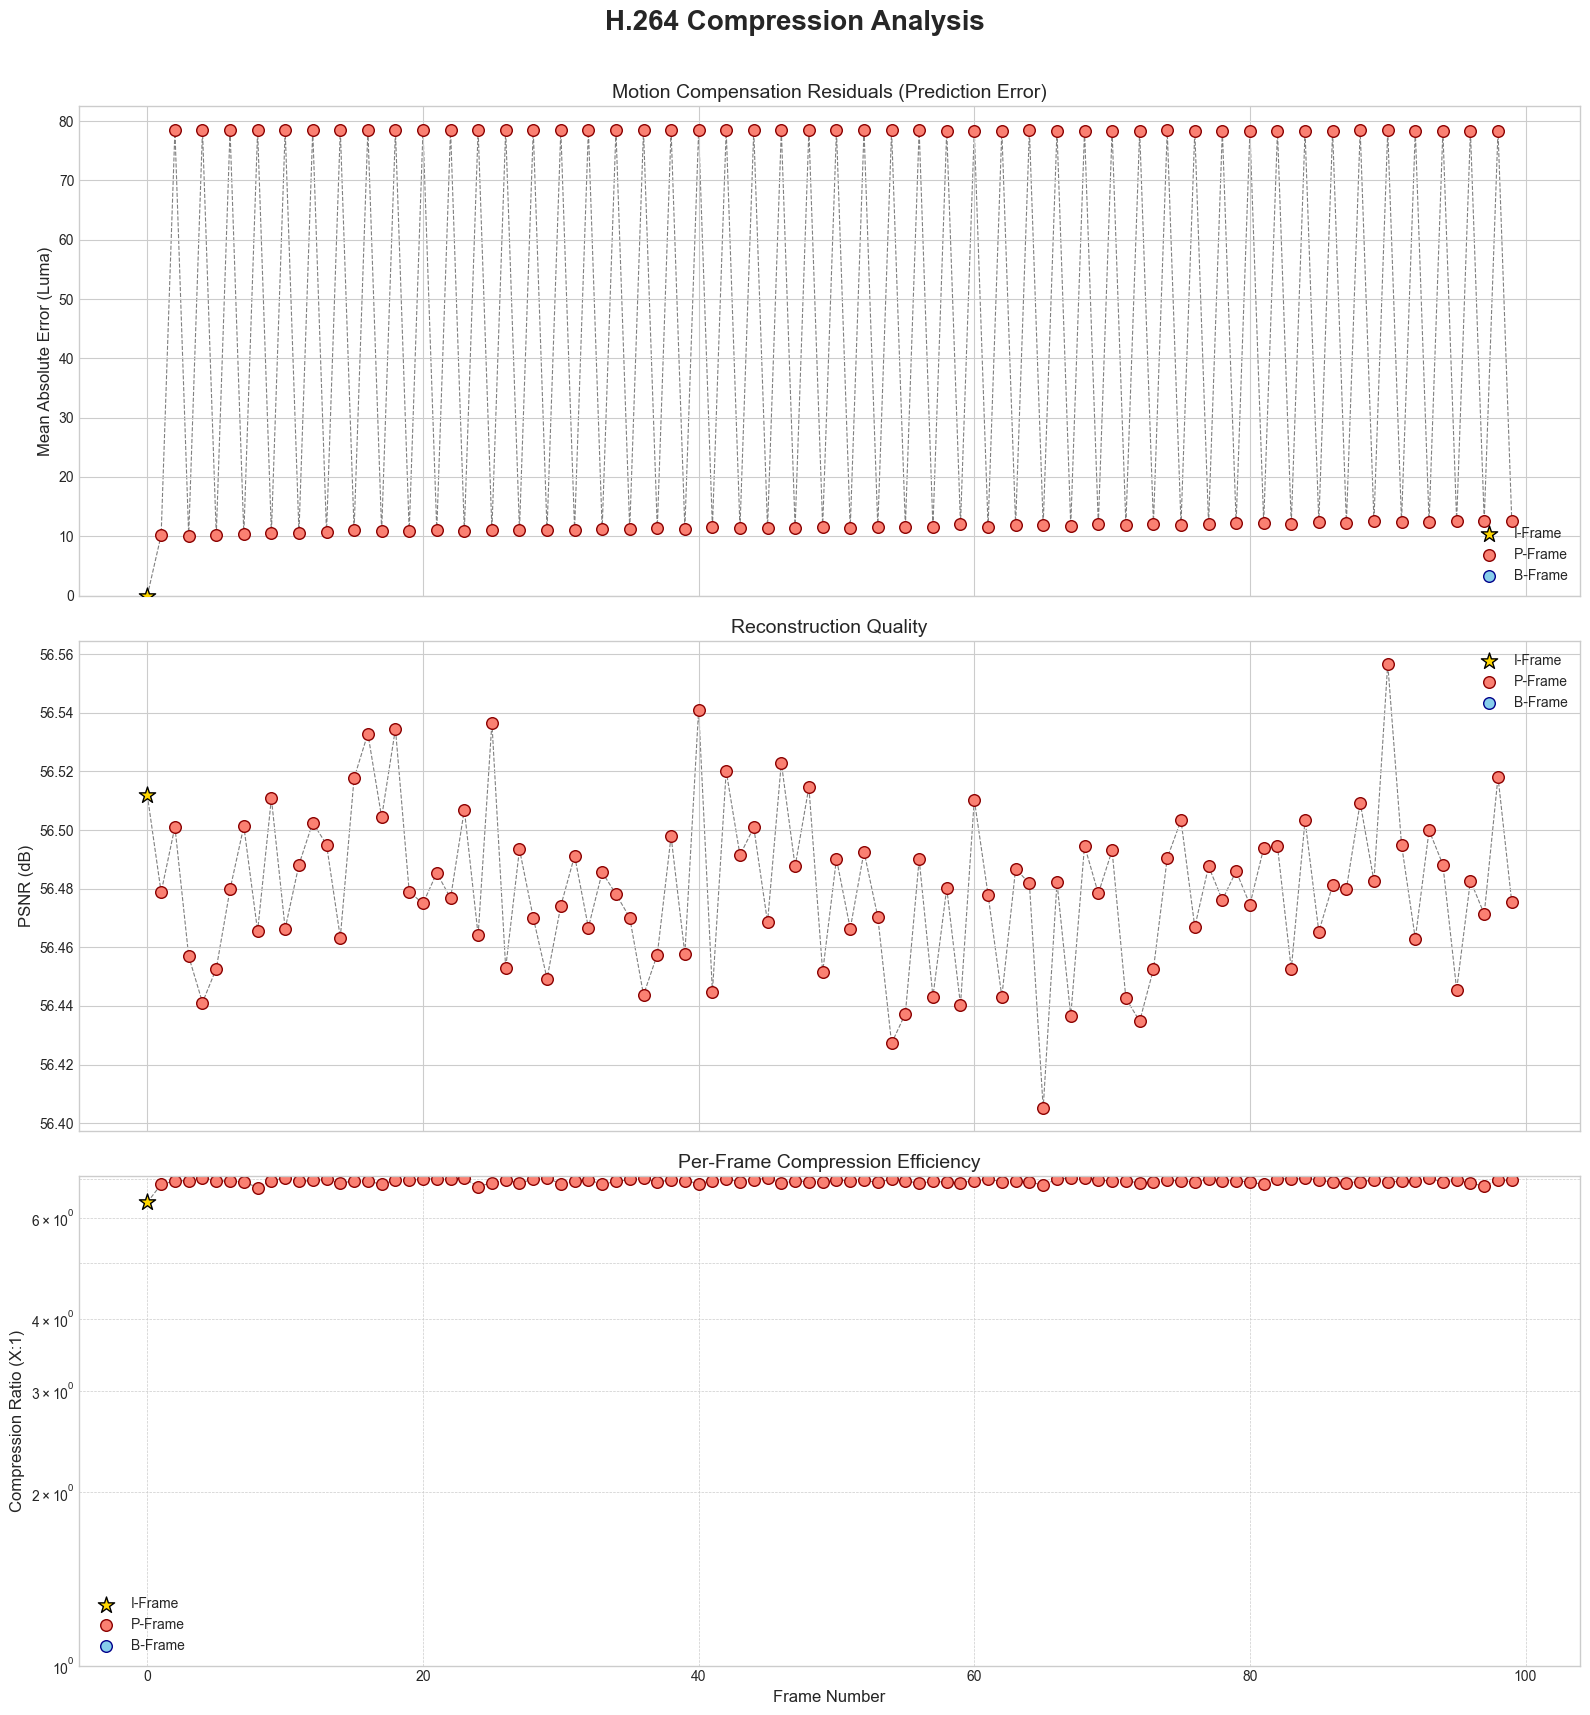


Cleaned up temporary files.
✓ Maximum Quality analysis completed

✅ H.264 analysis completed for 1 settings


In [8]:
# H.264 Compression Analysis
print("🎥 Running H.264 Compression Analysis...")
print("=" * 60)

if COMPRESSION_UTILS_LOADED:
    try:
        # Test different compression settings
        compression_settings = [
            # {'preset': 'medium', 'crf': 23, 'name': 'Default Quality'},
            # {'preset': 'medium', 'crf': 18, 'name': 'High Quality'},
            # {'preset': 'medium', 'crf': 28, 'name': 'Lower Quality'},
            {'preset': 'veryslow', 'crf': 0, 'name': 'Maximum Quality'},
        ]
        
        h264_results = {}
        
        for setting in compression_settings:
            print(f"\n🔧 Testing {setting['name']} (CRF={setting['crf']}, preset={setting['preset']})...")
            
            try:
                # Run H.264 compression analysis
                result = analyze_h264_compression(
                    video_uint8, 
                    preset=setting['preset'], 
                    crf=setting['crf'],
                    save_compressed_video=True
                )
                
                h264_results[setting['name']] = {
                    'crf': setting['crf'],
                    'preset': setting['preset']
                }
                
                print(f"✓ {setting['name']} analysis completed")
                
            except Exception as e:
                print(f"❌ {setting['name']} failed: {e}")
                continue
        
        print(f"\n✅ H.264 analysis completed for {len(h264_results)} settings")
        
    except Exception as e:
        print(f"❌ H.264 analysis failed: {e}")
        print("This may be due to missing FFmpeg installation")
        
else:
    print("⚠️  H.264 analysis not available without sdate.compression module")
    print("Showing basic compression statistics instead...")
    
    # Basic analysis without FFmpeg
    print(f"\nBasic Video Statistics:")
    print(f"  Uncompressed size: {uncompressed_size_8bit / 1e6:.2f} MB")
    print(f"  Frames: {video_uint8.shape[0]}")
    print(f"  Resolution: {video_uint8.shape[1]}x{video_uint8.shape[2]}")
    print(f"  Channels: {video_uint8.shape[3]}")
    print(f"  Bit depth: 8-bit (uint8)")

# Self-Implemented Video Compression Analysis

This section implements a comprehensive custom video compression analysis using the `VideoCompressor` from `sdate.compression`. The analysis includes:

1. **Custom Video Compression Pipeline**:
   - Motion estimation and compensation
   - DCT-based residual compression
   - Quantization with quality control
   - Huffman entropy coding
   
2. **Quality Assessment**:
   - PSNR and SSIM metrics
   - Visual quality comparison
   - Compression ratio analysis
   
3. **Parameter Studies**:
   - Different quality settings
   - Block size effects
   - Motion search range optimization

The custom compressor uses a hybrid approach combining:
- **I-frames**: JPEG compression for keyframes
- **P-frames**: Motion compensation + DCT residual coding
- **Entropy coding**: Huffman coding for optimal bit allocation

In [21]:
# Import self-implemented compression utilities
print("📦 Importing Self-Implemented Compression Utilities...")

try:
    from sdate.compression import VideoCompressor, DCTQuantizer
    CUSTOM_COMPRESSION_AVAILABLE = True
    print("✅ Successfully imported VideoCompressor and DCTQuantizer from sdate.compression")
except ImportError as e:
    CUSTOM_COMPRESSION_AVAILABLE = False
    print(f"❌ Failed to import custom compression utilities: {e}")
    print("   Make sure sdate package is properly installed")

# Check for required dependencies
try:
    import torch_dct
    import huffman
    DCT_HUFFMAN_AVAILABLE = True
    print("✅ Dependencies (torch_dct, huffman) are available")
except ImportError as e:
    DCT_HUFFMAN_AVAILABLE = False
    print(f"⚠️  Missing dependencies: {e}")
    print("   Install with: pip install torch-dct huffman")

if CUSTOM_COMPRESSION_AVAILABLE and DCT_HUFFMAN_AVAILABLE:
    print("\n🚀 Ready for self-implemented compression analysis!")
    
    # Configure analysis parameters
    COMPRESSION_SETTINGS = [
        {'block_size': 16, 'motion_range': 16, 'quality': 100, 'name': 'High Quality'},
        {'block_size': 16, 'motion_range': 16, 'quality': 80, 'name': 'Balanced Quality'},
        {'block_size': 8, 'motion_range': 8, 'quality': 100, 'name': 'Fine Blocks'},
    ]
    
    print(f"📋 Configured {len(COMPRESSION_SETTINGS)} compression settings for analysis")
    
else:
    print("⚠️  Custom compression analysis will be skipped due to missing dependencies")
    COMPRESSION_SETTINGS = []

📦 Importing Self-Implemented Compression Utilities...
✅ Successfully imported VideoCompressor and DCTQuantizer from sdate.compression
✅ Dependencies (torch_dct, huffman) are available

🚀 Ready for self-implemented compression analysis!
📋 Configured 3 compression settings for analysis


In [ ]:
# Self-Implemented Compression Analysis - Comprehensive Testing
if CUSTOM_COMPRESSION_AVAILABLE and DCT_HUFFMAN_AVAILABLE:
    print("🎬 Running Comprehensive Self-Implemented Compression Analysis...")
    print("=" * 80)
    
    # Results storage
    compression_results = {}
    
    # Calculate original data size
    original_tensor_size = video_normalized.numel() * video_normalized.element_size()
    print(f"📊 Original video data:")
    print(f"   Shape: {video_normalized.shape}")
    print(f"   Size: {original_tensor_size / 1e6:.2f} MB")
    print(f"   Data type: {video_normalized.dtype}")
    
    # Run compression tests for each setting
    for i, setting in enumerate(COMPRESSION_SETTINGS):
        print(f"\n{'='*20} Test {i+1}/{len(COMPRESSION_SETTINGS)}: {setting['name']} {'='*20}")
        print(f"Parameters: block_size={setting['block_size']}, motion_range={setting['motion_range']}, quality={setting['quality']}")
        
        try:
            # Create compressor with current settings
            compressor = VideoCompressor(
                block_size=setting['block_size'],
                motion_search_range=setting['motion_range'],
                quality=setting['quality']
            )
            
            # Compress the video
            print("🔄 Compressing video...")
            compressed_path = f"custom_compressed_{setting['name'].lower().replace(' ', '_')}"
            
            # Time the compression
            import time
            start_time = time.time()
            video_tensor = video_normalized.unsqueeze(1).expand(-1, 3, -1, -1)
            compressor.compress(video_tensor, compressed_path)
            compression_time = time.time() - start_time
            
            print(f"✅ Compression completed in {compression_time:.2f} seconds")
            
            # Calculate compressed size
            compressed_size = 0
            if os.path.exists(compressed_path):
                for file in os.listdir(compressed_path):
                    file_path = os.path.join(compressed_path, file)
                    if os.path.isfile(file_path):
                        compressed_size += os.path.getsize(file_path)
            
            # Decompress the video
            print("🔄 Decompressing video...")
            start_time = time.time()
            reconstructed_video = compressor.decompress(compressed_path).mean(dim=1)
            decompression_time = time.time() - start_time
            
            print(f"✅ Decompression completed in {decompression_time:.2f} seconds")
            
            # Calculate metrics
            print("📊 Calculating quality metrics...")
            
            # Ensure tensors are same size (handle potential size mismatches)
            min_frames = min(video_normalized.shape[0], reconstructed_video.shape[0])
            original_crop = video_normalized[:min_frames]
            reconstructed_crop = reconstructed_video[:min_frames]
            
            # PSNR calculation
            mse = torch.mean((original_crop - reconstructed_crop) ** 2)
            if mse > 0:
                psnr = 20 * torch.log10(1.0 / torch.sqrt(mse))
            else:
                psnr = float('inf')
            
            # SSIM calculation (simplified version)
            def calculate_ssim_batch(x, y):
                mu_x = torch.mean(x)
                mu_y = torch.mean(y)
                sigma_x = torch.var(x)
                sigma_y = torch.var(y)
                sigma_xy = torch.mean((x - mu_x) * (y - mu_y))
                
                c1 = 0.01 ** 2
                c2 = 0.03 ** 2
                
                ssim = ((2 * mu_x * mu_y + c1) * (2 * sigma_xy + c2)) / \
                        ((mu_x ** 2 + mu_y ** 2 + c1) * (sigma_x + sigma_y + c2))
                return ssim.item()
            
            ssim = calculate_ssim_batch(original_crop, reconstructed_crop)
            
            # Compression ratio
            compression_ratio = original_tensor_size / compressed_size if compressed_size > 0 else 0
            
            # Store results
            compression_results[setting['name']] = {
                'settings': setting,
                'psnr': psnr.item() if isinstance(psnr, torch.Tensor) else psnr,
                'ssim': ssim,
                'compression_ratio': compression_ratio,
                'original_size_mb': original_tensor_size / 1e6,
                'compressed_size_mb': compressed_size / 1e6,
                'compression_time': compression_time,
                'decompression_time': decompression_time,
                'reconstructed_video': reconstructed_crop[:10].clone()  # Store first 10 frames for visualization
            }
            
            # Print summary
            print(f"📈 Results Summary:")
            print(f"   PSNR: {psnr:.2f} dB")
            print(f"   SSIM: {ssim:.4f}")
            print(f"   Compression Ratio: {compression_ratio:.1f}:1")
            print(f"   Compressed Size: {compressed_size / 1e6:.2f} MB")
            print(f"   Space Savings: {(1 - compressed_size/original_tensor_size)*100:.1f}%")
            
        except Exception as e:
            print(f"❌ Error in {setting['name']}: {e}")
            compression_results[setting['name']] = {
                'error': str(e),
                'settings': setting
            }
            continue
    
    print(f"\n✅ Compression analysis completed for {len([r for r in compression_results.values() if 'error' not in r])} settings")
else:
    print("⚠️  Skipping custom compression analysis - dependencies not available")
    compression_results = {}

🎬 Running Comprehensive Self-Implemented Compression Analysis...
📊 Original video data:
   Shape: torch.Size([401, 2016, 2016])
   Size: 6519.07 MB
   Data type: torch.float32

==================== Test 1/3: High Quality ====================
Parameters: block_size=16, motion_range=16, quality=100
Using device: cpu
🔄 Compressing video...


  0%|          | 0/400 [00:00<?, ?it/s]

Compression complete.
✅ Compression completed in 1202.75 seconds
🔄 Decompressing video...


0it [00:00, ?it/s]

Decompression complete.


📊 Custom Compression Results Analysis
📋 Compression Performance Summary:
   Configuration  Block Size  Motion Range  Quality  PSNR (dB)  SSIM  Compression Ratio  Compressed Size (MB)  Compression Time (s)  Decompression Time (s)
    High Quality          16            16      100     41.807 0.999              6.356                 8.549                14.580                   9.591
Balanced Quality          16            16       80     35.246 0.997              9.669                 5.620                11.670                   7.282
     Fine Blocks           8             8      100     39.272 0.999              7.642                 7.111                13.431                   8.580

🏆 Best Performers:
   Best PSNR: High Quality (41.81 dB)
   Best Compression: Balanced Quality (9.7:1)
   Best SSIM: High Quality (0.9994)


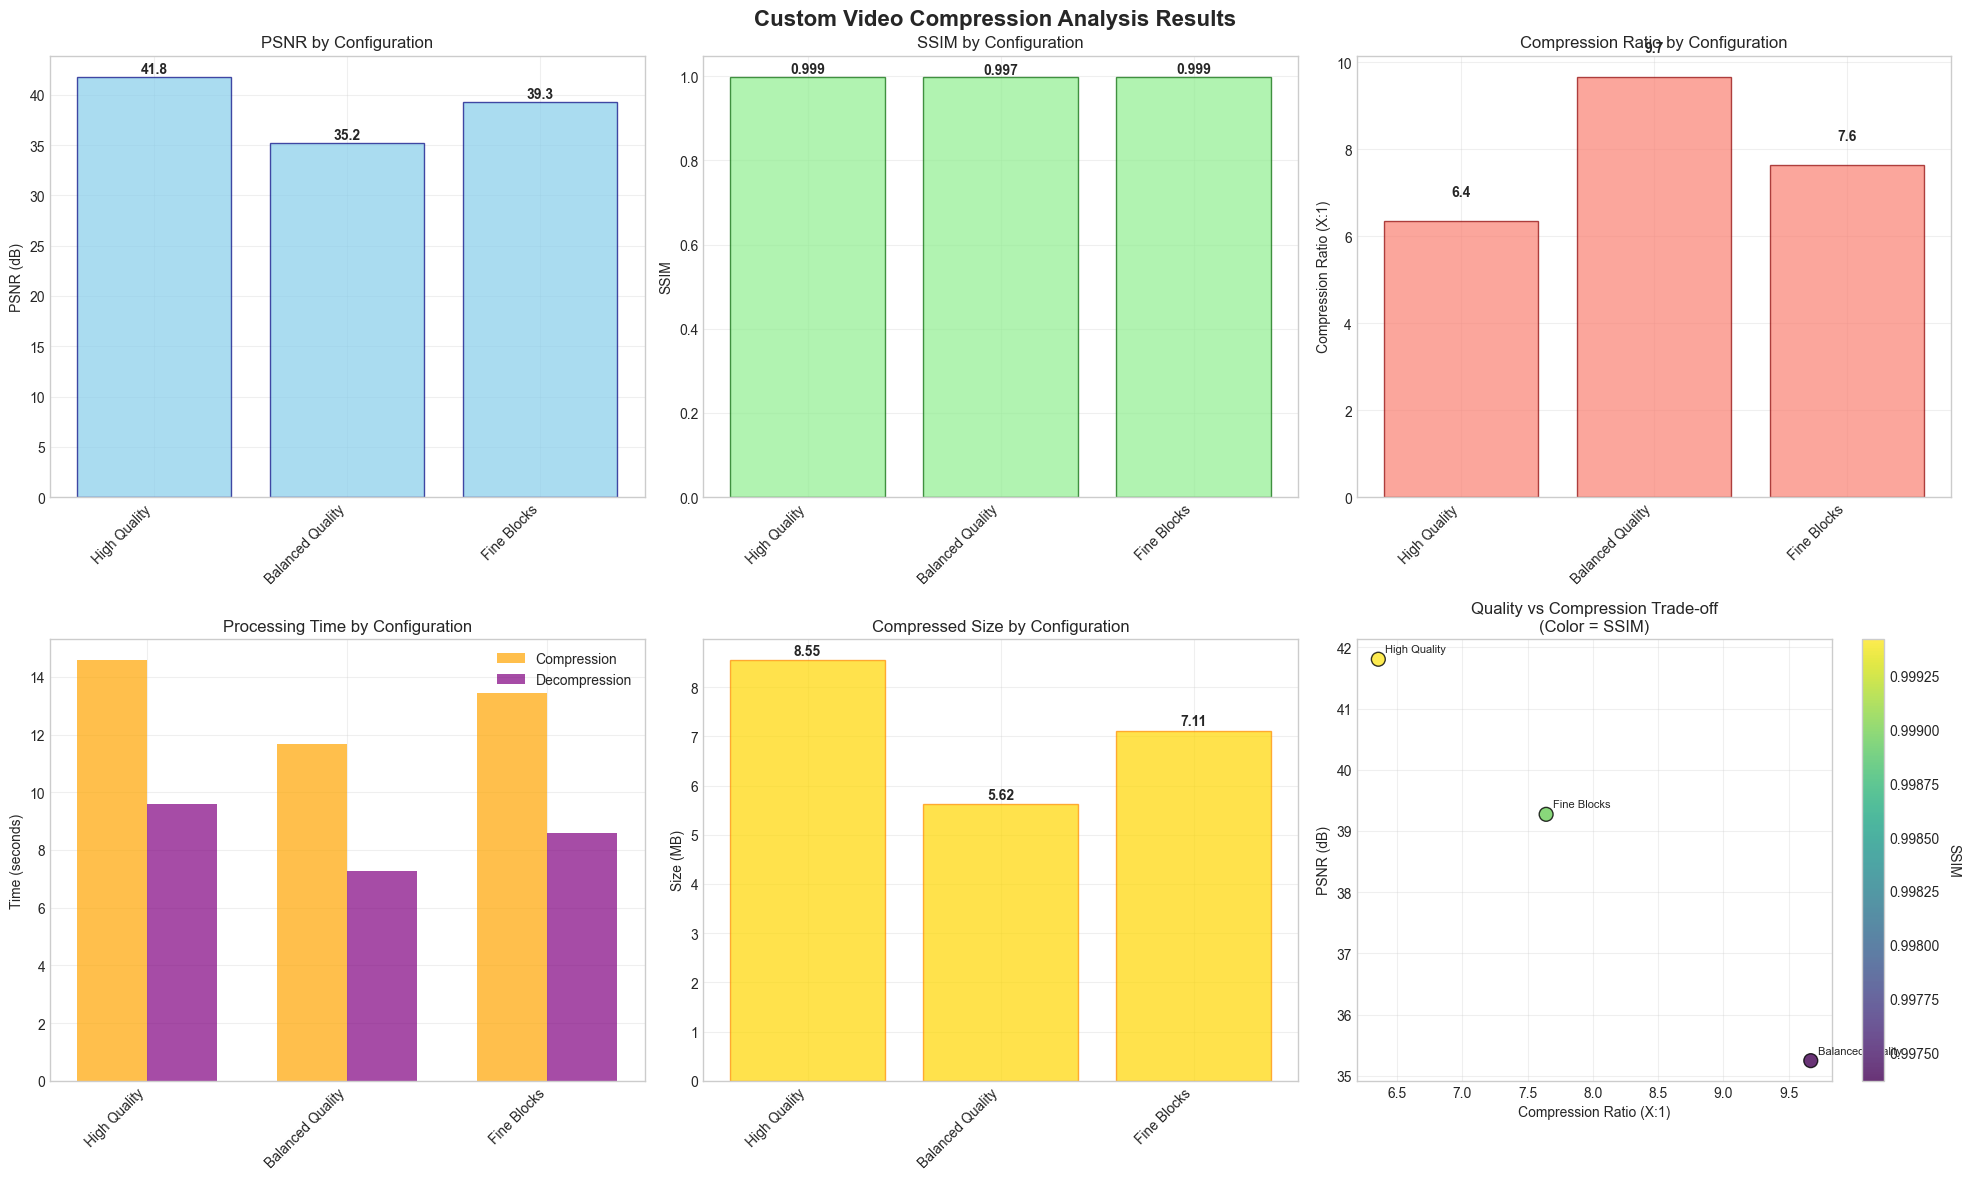

In [ ]:
# Analyze and Visualize Custom Compression Results
if compression_results and any('error' not in result for result in compression_results.values()):
    print("📊 Custom Compression Results Analysis")
    print("=" * 60)
    
    # Filter successful results
    successful_results = {name: result for name, result in compression_results.items() 
                         if 'error' not in result}
    
    # Create summary DataFrame for easy comparison
    summary_data = []
    for name, result in successful_results.items():
        summary_data.append({
            'Configuration': name,
            'Block Size': result['settings']['block_size'],
            'Motion Range': result['settings']['motion_range'],
            'Quality': result['settings']['quality'],
            'PSNR (dB)': result['psnr'],
            'SSIM': result['ssim'],
            'Compression Ratio': result['compression_ratio'],
            'Compressed Size (MB)': result['compressed_size_mb'],
            'Compression Time (s)': result['compression_time'],
            'Decompression Time (s)': result['decompression_time']
        })
    
    import pandas as pd
    df_results = pd.DataFrame(summary_data)
    
    print("📋 Compression Performance Summary:")
    print(df_results.round(3).to_string(index=False))
    
    # Find best performers
    print(f"\n🏆 Best Performers:")
    if len(df_results) > 0:
        best_psnr = df_results.loc[df_results['PSNR (dB)'].idxmax()]
        best_ratio = df_results.loc[df_results['Compression Ratio'].idxmax()]
        best_ssim = df_results.loc[df_results['SSIM'].idxmax()]
        
        print(f"   Best PSNR: {best_psnr['Configuration']} ({best_psnr['PSNR (dB)']:.2f} dB)")
        print(f"   Best Compression: {best_ratio['Configuration']} ({best_ratio['Compression Ratio']:.1f}:1)")
        print(f"   Best SSIM: {best_ssim['Configuration']} ({best_ssim['SSIM']:.4f})")
    
    # Visualization
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle('Custom Video Compression Analysis Results', fontsize=16, fontweight='bold')
    
    configs = list(successful_results.keys())
    psnr_values = [successful_results[c]['psnr'] for c in configs]
    ssim_values = [successful_results[c]['ssim'] for c in configs]
    ratios = [successful_results[c]['compression_ratio'] for c in configs]
    comp_times = [successful_results[c]['compression_time'] for c in configs]
    decomp_times = [successful_results[c]['decompression_time'] for c in configs]
    sizes = [successful_results[c]['compressed_size_mb'] for c in configs]
    
    # PSNR comparison
    bars1 = axes[0, 0].bar(range(len(configs)), psnr_values, color='skyblue', edgecolor='navy', alpha=0.7)
    axes[0, 0].set_title('PSNR by Configuration')
    axes[0, 0].set_ylabel('PSNR (dB)')
    axes[0, 0].set_xticks(range(len(configs)))
    axes[0, 0].set_xticklabels(configs, rotation=45, ha='right')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Add value labels on bars
    for bar, value in zip(bars1, psnr_values):
        axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                        f'{value:.1f}', ha='center', va='bottom', fontweight='bold')
    
    # SSIM comparison
    bars2 = axes[0, 1].bar(range(len(configs)), ssim_values, color='lightgreen', edgecolor='darkgreen', alpha=0.7)
    axes[0, 1].set_title('SSIM by Configuration')
    axes[0, 1].set_ylabel('SSIM')
    axes[0, 1].set_xticks(range(len(configs)))
    axes[0, 1].set_xticklabels(configs, rotation=45, ha='right')
    axes[0, 1].grid(True, alpha=0.3)
    
    for bar, value in zip(bars2, ssim_values):
        axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
                        f'{value:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # Compression ratio
    bars3 = axes[0, 2].bar(range(len(configs)), ratios, color='salmon', edgecolor='darkred', alpha=0.7)
    axes[0, 2].set_title('Compression Ratio by Configuration')
    axes[0, 2].set_ylabel('Compression Ratio (X:1)')
    axes[0, 2].set_xticks(range(len(configs)))
    axes[0, 2].set_xticklabels(configs, rotation=45, ha='right')
    axes[0, 2].grid(True, alpha=0.3)
    
    for bar, value in zip(bars3, ratios):
        axes[0, 2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                        f'{value:.1f}', ha='center', va='bottom', fontweight='bold')
    
    # Timing comparison
    x_pos = np.arange(len(configs))
    width = 0.35
    axes[1, 0].bar(x_pos - width/2, comp_times, width, label='Compression', color='orange', alpha=0.7)
    axes[1, 0].bar(x_pos + width/2, decomp_times, width, label='Decompression', color='purple', alpha=0.7)
    axes[1, 0].set_title('Processing Time by Configuration')
    axes[1, 0].set_ylabel('Time (seconds)')
    axes[1, 0].set_xticks(x_pos)
    axes[1, 0].set_xticklabels(configs, rotation=45, ha='right')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Size comparison
    bars5 = axes[1, 1].bar(range(len(configs)), sizes, color='gold', edgecolor='darkorange', alpha=0.7)
    axes[1, 1].set_title('Compressed Size by Configuration')
    axes[1, 1].set_ylabel('Size (MB)')
    axes[1, 1].set_xticks(range(len(configs)))
    axes[1, 1].set_xticklabels(configs, rotation=45, ha='right')
    axes[1, 1].grid(True, alpha=0.3)
    
    for bar, value in zip(bars5, sizes):
        axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
                        f'{value:.2f}', ha='center', va='bottom', fontweight='bold')
    
    # Quality vs Compression trade-off
    axes[1, 2].scatter(ratios, psnr_values, s=100, c=ssim_values, cmap='viridis', alpha=0.8, edgecolors='black')
    for i, config in enumerate(configs):
        axes[1, 2].annotate(config, (ratios[i], psnr_values[i]), 
                           xytext=(5, 5), textcoords='offset points', fontsize=8)
    axes[1, 2].set_xlabel('Compression Ratio (X:1)')
    axes[1, 2].set_ylabel('PSNR (dB)')
    axes[1, 2].set_title('Quality vs Compression Trade-off\n(Color = SSIM)')
    axes[1, 2].grid(True, alpha=0.3)
    
    # Add colorbar for SSIM
    cbar = plt.colorbar(axes[1, 2].collections[0], ax=axes[1, 2])
    cbar.set_label('SSIM', rotation=270, labelpad=15)
    
    plt.tight_layout()
    plt.show()
    
else:
    print("⚠️  No successful compression results to analyze")